# NB04: THINGS Ingestion — Overlap Galaxies

**Purpose:** Ingest THINGS rotation curves for the 13 SPARC-overlap galaxies.
Pair with existing SPARC baryonic profiles. Store combined profiles in the database
for RT fitting in Block 3.

**Data source:** de Blok et al. (2008, AJ 136, 2648) rotation curves via
Garcia-Arroyo et al. (2026) redistribution.

**Key design choice:** For overlap galaxies, THINGS provides the *kinematics*
(V_obs, V_err) while SPARC provides the *baryonic decomposition* (V_gas, V_disk,
V_bulge). This isolates kinematic differences between pipelines while holding the
baryonic baseline constant.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.ingest import (
    load_things_overlap_csv, load_things_rotation_curve,
    load_galaxy_profiles, get_things_distances,
)
from src.physics import compute_v_bary
from src.database import get_engine, get_session, Galaxy, RadialProfile, init_db
from src.database import query_profiles_as_dataframe
from src.utils import get_project_root

root = get_project_root()
results_dir = root / "results"
results_dir.mkdir(exist_ok=True)
things_curves_dir = root / "data" / "raw" / "THINGS" / "Curves"

## 1. Load Overlap Mapping and SPARC Distances

In [2]:
overlap, nonoverlap = load_things_overlap_csv()
print(f"Overlap galaxies: {len(overlap)}")
print(f"Non-overlap galaxies: {len(nonoverlap)}")
print()
for entry in overlap:
    print(f"  {entry['things_name']:12s} -> SPARC: {entry['sparc_name']}")

# Load SPARC distances from database
import sqlalchemy
engine = get_engine()
with engine.connect() as conn:
    rows = conn.execute(sqlalchemy.text(
        "SELECT galaxy_id, distance_mpc FROM galaxies"
    )).fetchall()
sparc_distances = {r[0]: r[1] for r in rows}

# Use SPARC distances for overlap galaxies (consistency with baryonic profiles)
print()
for entry in overlap:
    sid = entry["sparc_name"]
    entry["distance_mpc"] = sparc_distances[sid]
    print(f"  {sid}: {entry['distance_mpc']:.2f} Mpc (SPARC)")

2026-04-09 19:38:59 | INFO     | src.ingest | THINGS overlap: 13, non-overlap: 6


Overlap galaxies: 13
Non-overlap galaxies: 6

  DDO 154      -> SPARC: DDO154
  IC 2574      -> SPARC: IC2574
  NGC 2366     -> SPARC: NGC2366
  NGC 2403     -> SPARC: NGC2403
  NGC 2841     -> SPARC: NGC2841
  NGC 2903     -> SPARC: NGC2903
  NGC 2976     -> SPARC: NGC2976
  NGC 3198     -> SPARC: NGC3198
  NGC 3521     -> SPARC: NGC3521
  NGC 5055     -> SPARC: NGC5055
  NGC 6946     -> SPARC: NGC6946
  NGC 7331     -> SPARC: NGC7331
  NGC 7793     -> SPARC: NGC7793

  DDO154: 4.04 Mpc (SPARC)
  IC2574: 3.91 Mpc (SPARC)
  NGC2366: 3.27 Mpc (SPARC)
  NGC2403: 3.16 Mpc (SPARC)
  NGC2841: 14.10 Mpc (SPARC)
  NGC2903: 6.60 Mpc (SPARC)
  NGC2976: 3.58 Mpc (SPARC)
  NGC3198: 13.80 Mpc (SPARC)
  NGC3521: 7.70 Mpc (SPARC)
  NGC5055: 9.90 Mpc (SPARC)
  NGC6946: 5.52 Mpc (SPARC)
  NGC7331: 14.70 Mpc (SPARC)
  NGC7793: 3.61 Mpc (SPARC)


## 2. Parse THINGS Rotation Curves

In [3]:
things_rc = {}
for entry in overlap:
    fname = entry["file_name"]
    curve_path = things_curves_dir / f"{fname}.curve.02"
    rc = load_things_rotation_curve(str(curve_path), entry["distance_mpc"])
    things_rc[entry["sparc_name"]] = rc
    print(f"  {entry['sparc_name']:10s}: {len(rc):3d} points, "
          f"R_max = {rc['radius_kpc'].max():.2f} kpc")

2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: DDO154.curve (61 points, R_max=7.77 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: IC2574.curve (100 points, R_max=11.37 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC2366.curve (75 points, R_max=7.13 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC2403.curve (288 points, R_max=17.65 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC2841.curve (141 points, R_max=51.61 kpc)


...

2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC5055.curve (199 points, R_max=47.76 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC6946.curve (207 points, R_max=17.90 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC7331.curve (105 points, R_max=25.23 kpc)


2026-04-09 19:38:59 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC7793.curve (68 points, R_max=7.14 kpc)


  DDO154    :  61 points, R_max = 7.77 kpc
  IC2574    : 100 points, R_max = 11.37 kpc
  NGC2366   :  75 points, R_max = 7.13 kpc
  NGC2403   : 288 points, R_max = 17.65 kpc
  NGC2841   : 141 points, R_max = 51.61 kpc
  NGC2903   :  97 points, R_max = 21.73 kpc
  NGC2976   :  42 points, R_max = 2.55 kpc
  NGC3198   :  94 points, R_max = 37.73 kpc
  NGC3521   : 100 points, R_max = 22.40 kpc
  NGC5055   : 199 points, R_max = 47.76 kpc
  NGC6946   : 207 points, R_max = 17.90 kpc
  NGC7331   : 105 points, R_max = 25.23 kpc
  NGC7793   :  68 points, R_max = 7.14 kpc


## 3. Load SPARC Baryonic Profiles

In [4]:
sparc_profiles = {}
for entry in overlap:
    sid = entry["sparc_name"]
    df = load_galaxy_profiles(sid)
    sparc_profiles[sid] = df
    print(f"  {sid:10s}: {len(df):3d} points, "
          f"R_max = {df['radius_kpc'].max():.2f} kpc")

  DDO154    :  12 points, R_max = 5.92 kpc
  IC2574    :  34 points, R_max = 10.23 kpc
  NGC2366   :  26 points, R_max = 6.06 kpc
  NGC2403   :  73 points, R_max = 20.87 kpc
  NGC2841   :  50 points, R_max = 63.64 kpc
  NGC2903   :  34 points, R_max = 24.96 kpc
  NGC2976   :  27 points, R_max = 2.27 kpc
  NGC3198   :  43 points, R_max = 44.08 kpc
  NGC3521   :  41 points, R_max = 17.74 kpc
  NGC5055   :  28 points, R_max = 54.59 kpc
  NGC6946   :  58 points, R_max = 20.40 kpc
  NGC7331   :  36 points, R_max = 36.31 kpc
  NGC7793   :  46 points, R_max = 7.87 kpc


## 4. QC Summary Table

Compare radial coverage between THINGS and SPARC. Flag galaxies where THINGS
extends significantly beyond SPARC (`R_max` ratio > 1.2), as baryonic profiles
cannot be extrapolated reliably.

In [5]:
galaxy_ids = [e["sparc_name"] for e in overlap]

qc_rows = []
for entry in overlap:
    sid = entry["sparc_name"]
    rc = things_rc[sid]
    sp = sparc_profiles[sid]
    rmax_things = rc["radius_kpc"].max()
    rmax_sparc = sp["radius_kpc"].max()
    ratio = rmax_things / rmax_sparc
    flag = "***" if ratio > 1.2 else ""
    qc_rows.append({
        "galaxy_id": sid,
        "N_things": len(rc),
        "N_sparc": len(sp),
        "Rmax_things_kpc": round(rmax_things, 2),
        "Rmax_sparc_kpc": round(rmax_sparc, 2),
        "Rmax_ratio": round(ratio, 3),
        "flag": flag,
    })

qc_df = pd.DataFrame(qc_rows)
print(qc_df.to_string(index=False))
print()
flagged = qc_df[qc_df["flag"] != ""]
if len(flagged) > 0:
    print(f"WARNING: {len(flagged)} galaxies have THINGS R_max > 1.2x SPARC R_max.")
    print("These will be truncated at SPARC R_max during baryonic interpolation.")
    for _, row in flagged.iterrows():
        print(f"  {row['galaxy_id']}: THINGS {row['Rmax_things_kpc']} kpc vs "
              f"SPARC {row['Rmax_sparc_kpc']} kpc (ratio {row['Rmax_ratio']})")
else:
    print("No galaxies flagged for radial coverage mismatch.")

galaxy_id  N_things  N_sparc  Rmax_things_kpc  Rmax_sparc_kpc  Rmax_ratio flag
   DDO154        61       12             7.77            5.92       1.312  ***
   IC2574       100       34            11.37           10.23       1.112     
  NGC2366        75       26             7.13            6.06       1.177     
  NGC2403       288       73            17.65           20.87       0.846     
  NGC2841       141       50            51.61           63.64       0.811     
  NGC2903        97       34            21.73           24.96       0.870     
  NGC2976        42       27             2.55            2.27       1.124     
  NGC3198        94       43            37.73           44.08       0.856     
  NGC3521       100       41            22.40           17.74       1.263  ***
  NGC5055       199       28            47.76           54.59       0.875     
  NGC6946       207       58            17.90           20.40       0.878     
  NGC7331       105       36            25.23       

## 5. Rotation Curve Overlays

Visual comparison of THINGS and SPARC V_obs for each overlap galaxy.

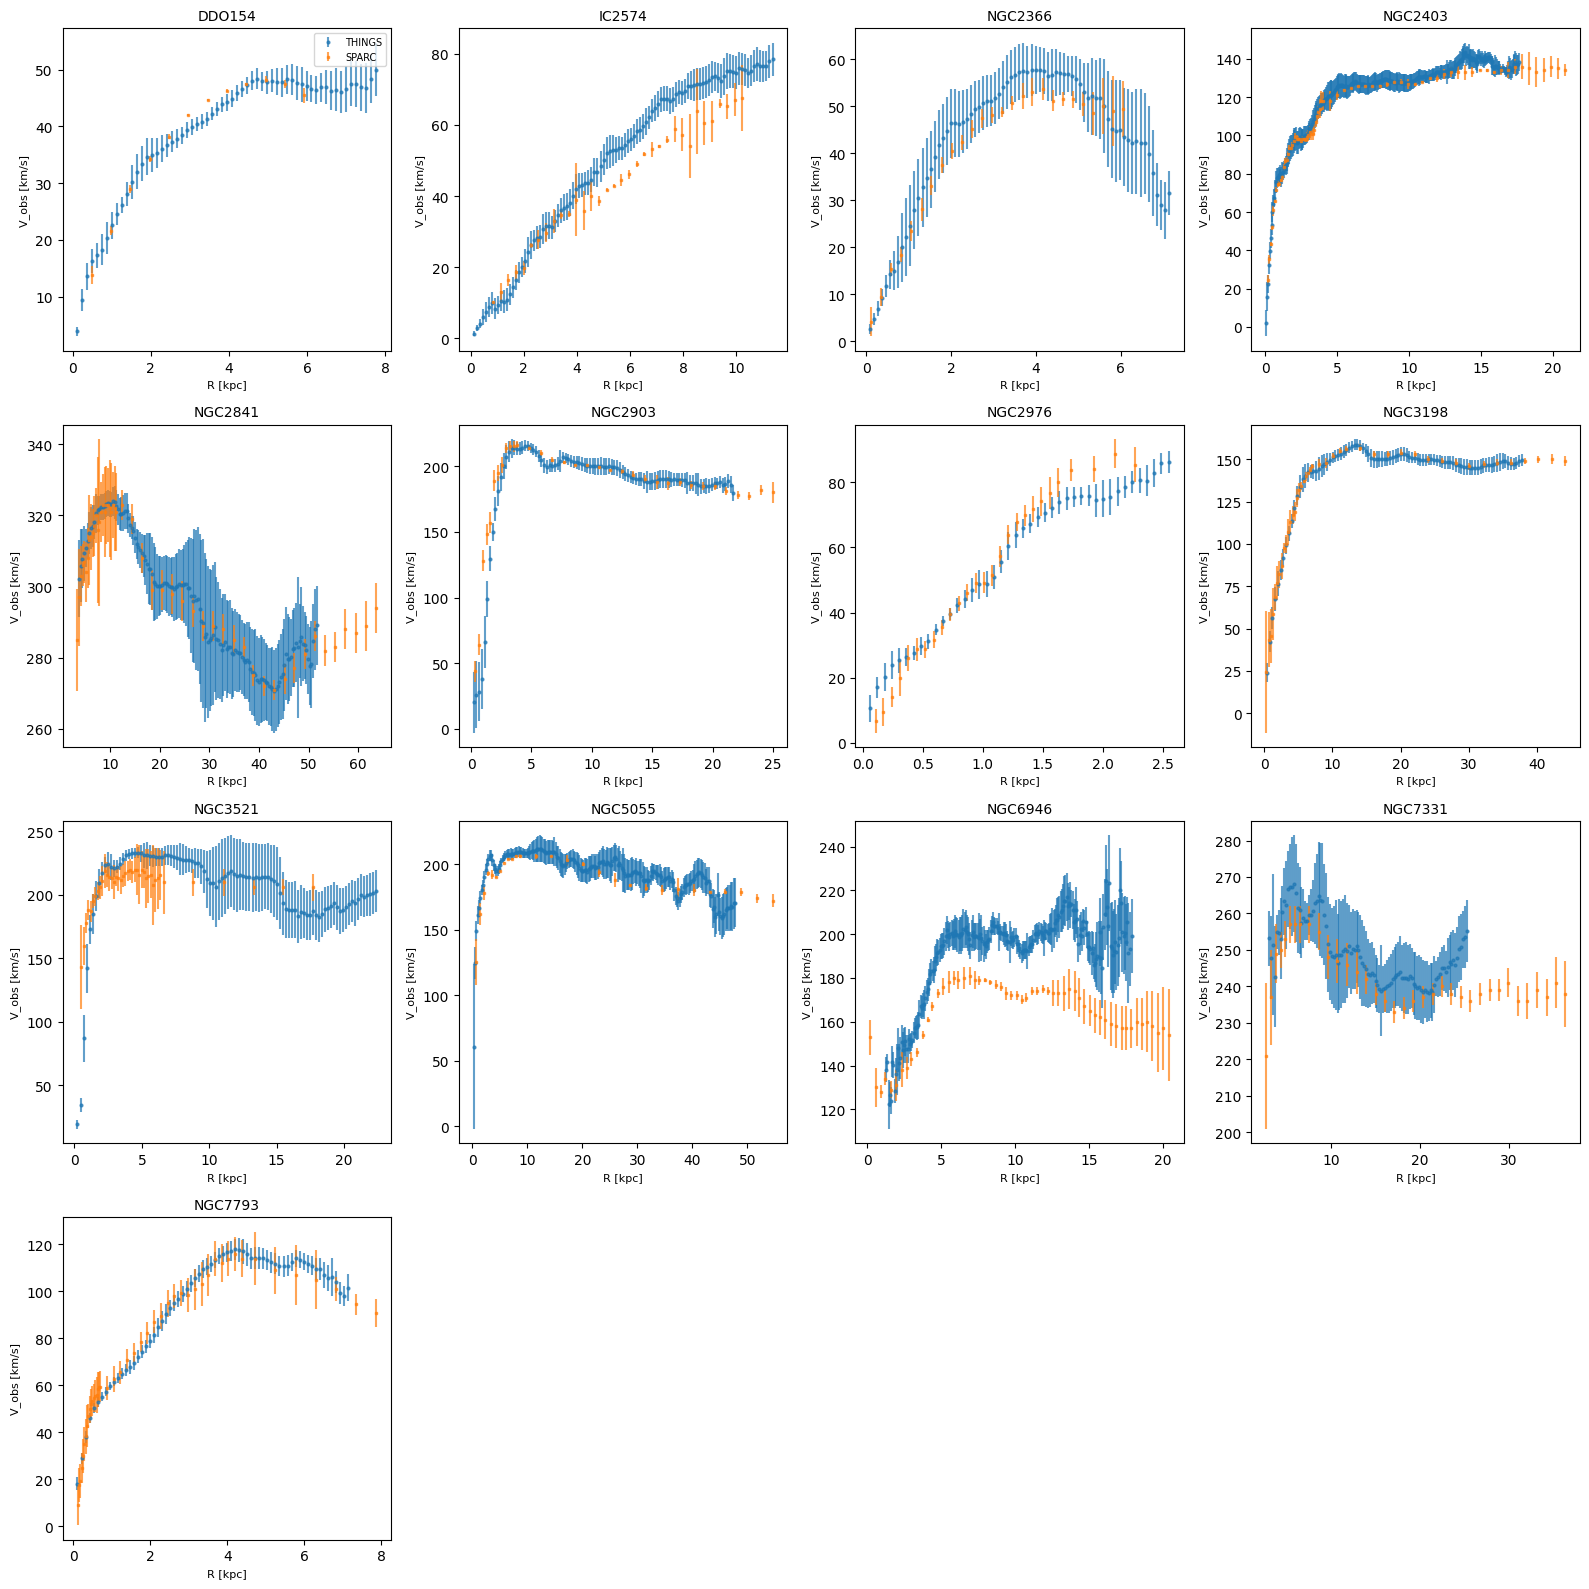

In [6]:
n_gal = len(galaxy_ids)
ncols = 4
nrows = (n_gal + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
for i, gid in enumerate(galaxy_ids):
    ax = axes[i // ncols][i % ncols]
    rc = things_rc[gid]
    sp = sparc_profiles[gid]
    ax.errorbar(rc["radius_kpc"], rc["v_obs"], yerr=rc["v_err"],
                fmt="o", ms=2, color="C0", alpha=0.7, label="THINGS")
    ax.errorbar(sp["radius_kpc"], sp["v_obs"], yerr=sp["v_err"],
                fmt="s", ms=2, color="C1", alpha=0.7, label="SPARC")
    ax.set_title(gid, fontsize=10)
    ax.set_xlabel("R [kpc]", fontsize=8)
    ax.set_ylabel("V_obs [km/s]", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

# Hide empty subplots
for j in range(n_gal, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.savefig(results_dir / "NB04_rc_overlay.png", dpi=150)
plt.show()

## 6. Interpolate SPARC Baryonic Profiles onto THINGS Radii

For each overlap galaxy, interpolate the SPARC baryonic components (V_gas, V_disk,
V_bulge) from the SPARC radial grid onto the THINGS radial grid using the
signed-square convention (same as `physics.py:interpolate_v_bary`).

THINGS data points beyond SPARC R_max are truncated — no baryonic baseline exists
for extrapolation.

In [7]:
def interp_signed_square(r_sparc, v_sparc, r_things):
    """Interpolate a velocity component using the signed-square convention.

    Interpolates V^2 (with sign preserved) then recovers velocity.
    Returns NaN for points outside the SPARC radial range.
    """
    v2_signed = np.sign(v_sparc) * v_sparc**2
    v2_at_things = np.interp(r_things, r_sparc, v2_signed,
                              left=np.nan, right=np.nan)
    return np.sign(v2_at_things) * np.sqrt(np.abs(v2_at_things))


# Build combined profiles: THINGS kinematics + SPARC baryonic (interpolated)
combined_profiles = {}
truncation_log = []

for gid in galaxy_ids:
    rc = things_rc[gid]
    sp = sparc_profiles[gid]

    r_sparc = sp["radius_kpc"].values
    r_things = rc["radius_kpc"].values
    rmin_sparc = r_sparc[0]
    rmax_sparc = r_sparc[-1]

    # Truncate THINGS to SPARC radial range (both ends)
    mask = (r_things >= rmin_sparc) & (r_things <= rmax_sparc)
    n_dropped_inner = int(np.sum(r_things < rmin_sparc))
    n_dropped_outer = int(np.sum(r_things > rmax_sparc))
    if n_dropped_inner > 0 or n_dropped_outer > 0:
        truncation_log.append(
            f"  {gid}: dropped {n_dropped_inner} inner + {n_dropped_outer} outer "
            f"points outside SPARC range [{rmin_sparc:.3f}, {rmax_sparc:.2f}] kpc"
        )
    r_use = r_things[mask]

    # Interpolate each baryonic component
    v_gas_interp = interp_signed_square(r_sparc, sp["v_gas"].values, r_use)
    v_disk_interp = interp_signed_square(r_sparc, sp["v_disk"].values, r_use)
    v_bulge_interp = interp_signed_square(r_sparc, sp["v_bulge"].values, r_use)

    # Compute v_baryon_total
    v_bary = compute_v_bary(v_gas_interp, v_disk_interp, v_bulge_interp)

    combined = pd.DataFrame({
        "radius_kpc": r_use,
        "v_obs": rc["v_obs"].values[mask],
        "v_err": rc["v_err"].values[mask],
        "v_gas": v_gas_interp,
        "v_disk": v_disk_interp,
        "v_bulge": v_bulge_interp,
        "v_baryon_total": v_bary,
    })
    combined_profiles[gid] = combined

print(f"Combined profiles built for {len(combined_profiles)} galaxies.")
print()
if truncation_log:
    print("Truncation log (points outside SPARC radial range):")
    for line in truncation_log:
        print(line)
else:
    print("No truncation needed \u2014 all THINGS data within SPARC radial range.")

# Verify no NaN in baryonic columns
print()
for gid, df in combined_profiles.items():
    n_nan = df[["v_gas", "v_disk", "v_bulge", "v_baryon_total"]].isna().sum().sum()
    if n_nan > 0:
        print(f"WARNING: {gid} has {n_nan} NaN values in baryonic columns!")
    else:
        print(f"  {gid}: {len(df)} points, no NaN \u2014 OK")

Combined profiles built for 13 galaxies.

Truncation log (points outside SPARC radial range):
  DDO154: dropped 3 inner + 15 outer points outside SPARC range [0.490, 5.92] kpc
  IC2574: dropped 7 inner + 11 outer points outside SPARC range [0.850, 10.23] kpc
  NGC2366: dropped 1 inner + 12 outer points outside SPARC range [0.120, 6.06] kpc
  NGC2403: dropped 2 inner + 0 outer points outside SPARC range [0.160, 20.87] kpc
  NGC2903: dropped 1 inner + 0 outer points outside SPARC range [0.320, 24.96] kpc
  NGC2976: dropped 1 inner + 5 outer points outside SPARC range [0.110, 2.27] kpc
  NGC3521: dropped 2 inner + 21 outer points outside SPARC range [0.510, 17.74] kpc
  NGC5055: dropped 3 inner + 0 outer points outside SPARC range [0.720, 54.59] kpc
  NGC7793: dropped 1 inner + 0 outer points outside SPARC range [0.110, 7.87] kpc

  DDO154: 43 points, no NaN — OK
  IC2574: 82 points, no NaN — OK
  NGC2366: 62 points, no NaN — OK
  NGC2403: 286 points, no NaN — OK
  NGC2841: 141 points, no

## 7. Store in Database

Insert each overlap galaxy as `{SPARC_NAME}_THINGS` with `data_source='THINGS'`.
Radial profiles use THINGS kinematics (V_obs, V_err) and interpolated SPARC
baryonic components (V_gas, V_disk, V_bulge, V_baryon_total).

In [8]:
session = get_session(engine)

inserted_count = 0
skipped_count = 0

for entry in overlap:
    sid = entry["sparc_name"]
    things_id = f"{sid}_THINGS"

    # Check if already exists (idempotent)
    existing = session.query(Galaxy).filter_by(galaxy_id=things_id).first()
    if existing:
        print(f"  {things_id}: already exists, skipping.")
        skipped_count += 1
        continue

    # Create Galaxy entry
    galaxy = Galaxy(
        galaxy_id=things_id,
        distance_mpc=entry["distance_mpc"],
        data_source="THINGS",
    )
    session.add(galaxy)
    session.flush()  # ensure galaxy_id is available for FK

    # Create RadialProfile entries from combined profiles
    df = combined_profiles[sid]
    for _, row in df.iterrows():
        profile = RadialProfile(
            galaxy_id=things_id,
            radius_kpc=float(row["radius_kpc"]),
            v_obs=float(row["v_obs"]),
            v_err=float(row["v_err"]),
            v_gas=float(row["v_gas"]),
            v_disk=float(row["v_disk"]),
            v_bulge=float(row["v_bulge"]),
            v_baryon_total=float(row["v_baryon_total"]),
        )
        session.add(profile)

    session.commit()
    inserted_count += 1
    print(f"  {things_id}: {len(df)} profiles inserted.")

print(f"\nInserted {inserted_count} new THINGS overlap galaxies.")
if skipped_count:
    print(f"Skipped {skipped_count} (already in database).")
session.close()

  DDO154_THINGS: 43 profiles inserted.
  IC2574_THINGS: 82 profiles inserted.
  NGC2366_THINGS: 62 profiles inserted.
  NGC2403_THINGS: 286 profiles inserted.
  NGC2841_THINGS: 141 profiles inserted.
  NGC2903_THINGS: 96 profiles inserted.
  NGC2976_THINGS: 36 profiles inserted.
  NGC3198_THINGS: 94 profiles inserted.
  NGC3521_THINGS: 77 profiles inserted.
  NGC5055_THINGS: 196 profiles inserted.
  NGC6946_THINGS: 207 profiles inserted.
  NGC7331_THINGS: 105 profiles inserted.
  NGC7793_THINGS: 67 profiles inserted.

Inserted 13 new THINGS overlap galaxies.


## 8. Verify Database Insertion

In [9]:
session = get_session(engine)
things_galaxies = (
    session.query(Galaxy)
    .filter(Galaxy.data_source == "THINGS")
    .order_by(Galaxy.galaxy_id)
    .all()
)
print(f"THINGS galaxies in database: {len(things_galaxies)}")
for g in things_galaxies:
    n_profiles = session.query(RadialProfile).filter_by(galaxy_id=g.galaxy_id).count()
    print(f"  {g.galaxy_id:20s}: {n_profiles:3d} radial profiles, "
          f"d = {g.distance_mpc:.2f} Mpc")

# Spot-check: NGC2403_THINGS
test_df = query_profiles_as_dataframe(session, "NGC2403_THINGS")
print(f"\nNGC2403_THINGS sample (first 5 rows):")
print(test_df.head())
session.close()

THINGS galaxies in database: 13
  DDO154_THINGS       :  43 radial profiles, d = 4.04 Mpc
  IC2574_THINGS       :  82 radial profiles, d = 3.91 Mpc
  NGC2366_THINGS      :  62 radial profiles, d = 3.27 Mpc
  NGC2403_THINGS      : 286 radial profiles, d = 3.16 Mpc
  NGC2841_THINGS      : 141 radial profiles, d = 14.10 Mpc
  NGC2903_THINGS      :  96 radial profiles, d = 6.60 Mpc
  NGC2976_THINGS      :  36 radial profiles, d = 3.58 Mpc
  NGC3198_THINGS      :  94 radial profiles, d = 13.80 Mpc
  NGC3521_THINGS      :  77 radial profiles, d = 7.70 Mpc
  NGC5055_THINGS      : 196 radial profiles, d = 9.90 Mpc
  NGC6946_THINGS      : 207 radial profiles, d = 5.52 Mpc
  NGC7331_THINGS      : 105 radial profiles, d = 14.70 Mpc
  NGC7793_THINGS      :  67 radial profiles, d = 3.61 Mpc

NGC2403_THINGS sample (first 5 rows):
   radius_kpc  v_obs  v_err     v_gas     v_disk  v_bulge  v_baryon_total
0    0.183841  22.30  4.584  0.000000  26.605608      0.0       18.813006
1    0.245122  32.16  4.

## 9. Gate Check

In [10]:
session = get_session(engine)

# Count THINGS galaxies
n_things = session.query(Galaxy).filter(Galaxy.data_source == "THINGS").count()

# Verify all overlap galaxies have profiles
profile_counts = {}
for entry in overlap:
    tid = f"{entry['sparc_name']}_THINGS"
    profile_counts[tid] = session.query(RadialProfile).filter_by(galaxy_id=tid).count()
session.close()

checks = {
    "13 overlap galaxies ingested": n_things >= 13,
    "All galaxies have profiles": all(c > 0 for c in profile_counts.values()),
    "No NaN in baryonic columns": all(
        combined_profiles[gid][["v_gas", "v_disk", "v_bulge", "v_baryon_total"]].isna().sum().sum() == 0
        for gid in galaxy_ids
    ),
}

print("GATE CHECK: NB04 \u2014 THINGS Overlap Ingestion")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB04 COMPLETE \u2014 proceed to NB05 <<<")
else:
    print("  >>> NB04 FAILED \u2014 diagnose before continuing <<<")

# Save QC summary
qc_df.to_csv(results_dir / "NB04_overlap_qc.csv", index=False)
print(f"\nQC summary saved to results/NB04_overlap_qc.csv")

GATE CHECK: NB04 — THINGS Overlap Ingestion
  [PASS] 13 overlap galaxies ingested
  [PASS] All galaxies have profiles
  [PASS] No NaN in baryonic columns

  >>> NB04 COMPLETE — proceed to NB05 <<<

QC summary saved to results/NB04_overlap_qc.csv
